# 💬 Comment Category Prediction — Enhanced Notebook

This notebook includes:
- **EDA** with detailed visualizations and insights
- **Missing data handling** using sklearn Pipelines
- **Categorical encoding** (LabelEncoder + OrdinalEncoder via pipeline)
- **Hyperparameter Tuning** for LightGBM, Random Forest, and Naive Bayes
- **Model Comparison** with accuracy and visual benchmarking
- **Final Submission** using the best model (LightGBM pipeline kept as original)


In [3]:
# ============================================================
# 📌 CELL 1: IMPORTS & GLOBAL CONFIG
# ============================================================

import re
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.sparse import hstack

# --- Sklearn Utilities ---
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB

import lightgbm as lgb

# --- Config ---
SEED       = 42
N_SPLITS   = 5

# HPT settings — kept small intentionally:
#   • HPT_SUBSAMPLE : fraction of train used for tuning (dense matrix is huge)
#   • N_ITER_HPT    : RandomizedSearchCV candidates (8 × 3 folds = 24 fits total)
#   • SVD_COMPONENTS: lower = much faster HPT without losing meaningful signal
HPT_SUBSAMPLE  = 0.10   # only 10% of data for HPT — fast and still representative
N_ITER_HPT     = 8      # 8 candidates × 3 folds = 24 fits (was 20 × 3 = 60 — too slow)
SVD_COMPONENTS = 100    # reduced from 256; speeds up HPT significantly

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('✅ All imports loaded successfully.')
print(f'   HPT subsample : {HPT_SUBSAMPLE*100:.0f}% of training data')
print(f'   HPT iterations: {N_ITER_HPT} candidates × 3 folds = {N_ITER_HPT*3} fits per model')


✅ All imports loaded successfully.
   HPT subsample : 10% of training data
   HPT iterations: 8 candidates × 3 folds = 24 fits per model


In [4]:
# ============================================================
# 📌 CELL 2: LOAD DATA
# ============================================================

TRAIN_PATH  = '/kaggle/input/comment-category-prediction-challenge/train.csv'
TEST_PATH   = '/kaggle/input/comment-category-prediction-challenge/test.csv'
SAMPLE_PATH = '/kaggle/input/comment-category-prediction-challenge/Sample.csv'

train  = pd.read_csv(TRAIN_PATH)
test   = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH)

print(f'Train  shape : {train.shape}')
print(f'Test   shape : {test.shape}')
print(f'Sample shape : {sample.shape}')
train.head()

Train  shape : (198000, 15)
Test   shape : (102000, 14)
Sample shape : (102000, 2)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


---
## 🔍 Section 1 — Exploratory Data Analysis (EDA)

In [5]:
# ============================================================
# 📌 CELL 3: BASIC DATASET INFO
# ============================================================

print('=' * 60)
print('TRAIN DATASET — BASIC INFO')
print('=' * 60)
train.info()

print('\n--- Descriptive Statistics (Numeric Columns) ---')
train.describe(include='number').T

TRAIN DATASET — BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB

--- Descriptive Statistics (Numeric Columns) ---


,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0



TRAIN — columns with missing values: 4

TEST — columns with missing values: 3

TRAIN missing details:


,missing_count,missing_pct,dtype
race,145423,73.445960,object
religion,145423,73.445960,object
gender,145423,73.445960,object
comment,1,0.000505,object



TEST missing details:


,missing_count,missing_pct,dtype
race,75269,73.793137,object
religion,75269,73.793137,object
gender,75269,73.793137,object


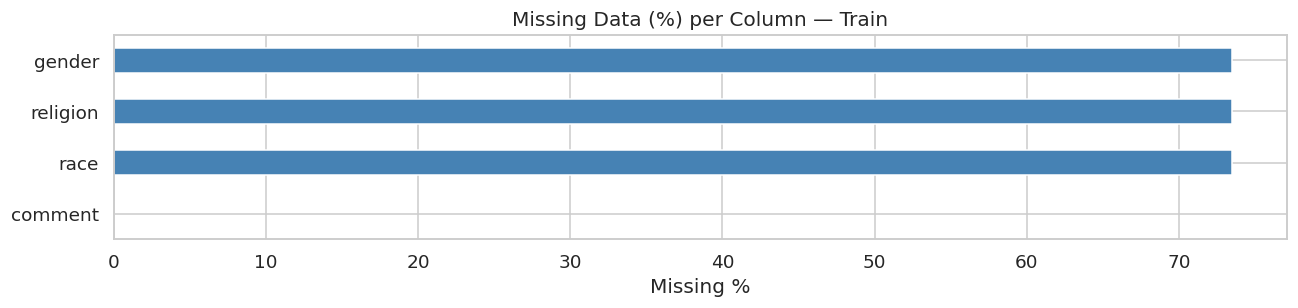

In [6]:
# ============================================================
# 📌 CELL 4: MISSING DATA ANALYSIS
# ============================================================
# Identify ALL columns with any missing values in train & test,
# visualise the extent of missingness, and plan the imputation strategy.

def missing_summary(df, name='DataFrame'):
    """Return a tidy summary of missing values per column."""
    miss  = df.isnull().sum()
    pct   = miss / len(df) * 100
    dtype = df.dtypes
    summary = (
        pd.DataFrame({'missing_count': miss, 'missing_pct': pct, 'dtype': dtype})
        .query('missing_count > 0')
        .sort_values('missing_pct', ascending=False)
    )
    print(f'\n{name} — columns with missing values: {len(summary)}')
    return summary

train_miss = missing_summary(train, 'TRAIN')
test_miss  = missing_summary(test,  'TEST')

print('\nTRAIN missing details:')
display(train_miss)

print('\nTEST missing details:')
display(test_miss)

# --- Visual: heatmap of missingness pattern ---
if not train_miss.empty:
    fig, ax = plt.subplots(figsize=(12, max(3, len(train_miss) * 0.5)))
    train_miss['missing_pct'].sort_values().plot(
        kind='barh', color='steelblue', ax=ax
    )
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Data (%) per Column — Train')
    plt.tight_layout()
    plt.show()
else:
    print('\n✅ No missing values detected in TRAIN!')

Label distribution (count & %):
        count  pct_%
label               
0      114173  57.66
2       62440  31.54
1       15918   8.04
3        5469   2.76


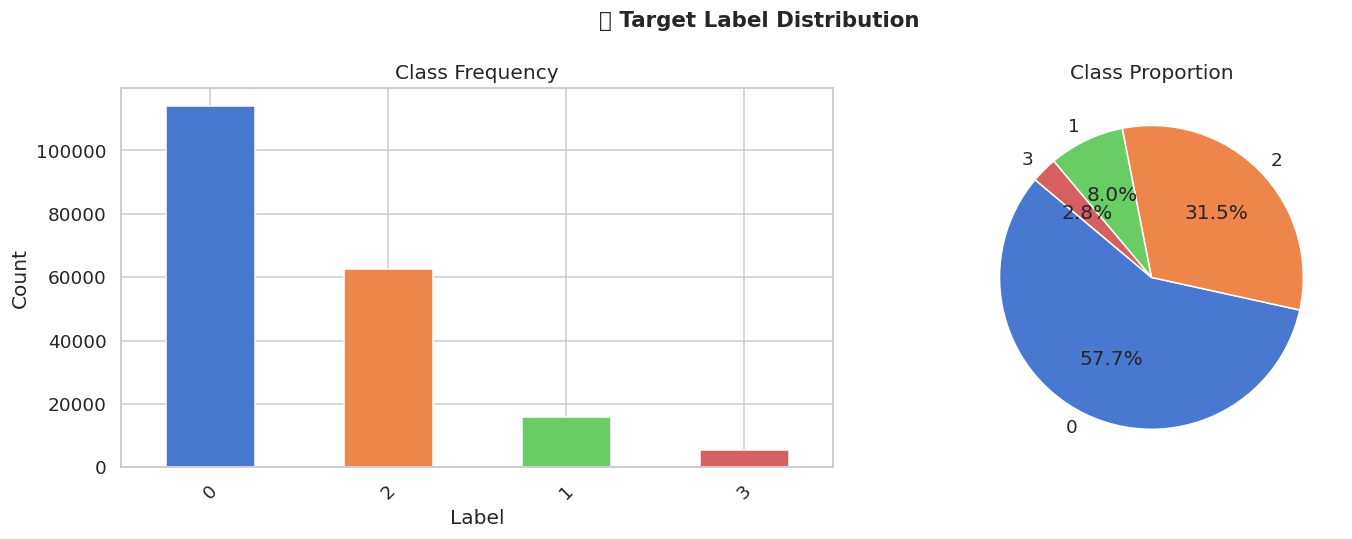


📌 Imbalance ratio (max / min class): 20.88x
⚠️  Significant class imbalance detected — consider class_weight or resampling.


In [7]:
# ============================================================
# 📌 CELL 5: TARGET DISTRIBUTION
# ============================================================
# Insight: Understanding class balance is critical — imbalanced
# classes can mislead accuracy and need appropriate handling.

label_counts = train['label'].value_counts()
label_pct    = train['label'].value_counts(normalize=True) * 100

print('Label distribution (count & %):')
print(pd.concat([label_counts, label_pct.round(2)], axis=1,
                keys=['count', 'pct_%']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(label_counts)))
axes[0].set_title('Class Frequency')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('muted', len(label_counts)),
    startangle=140
)
axes[1].set_title('Class Proportion')

plt.suptitle('📊 Target Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Imbalance check
max_pct = label_pct.max()
min_pct = label_pct.min()
ratio   = max_pct / min_pct
print(f'\n📌 Imbalance ratio (max / min class): {ratio:.2f}x')
if ratio > 5:
    print('⚠️  Significant class imbalance detected — consider class_weight or resampling.')
else:
    print('✅  Class distribution is reasonably balanced.')

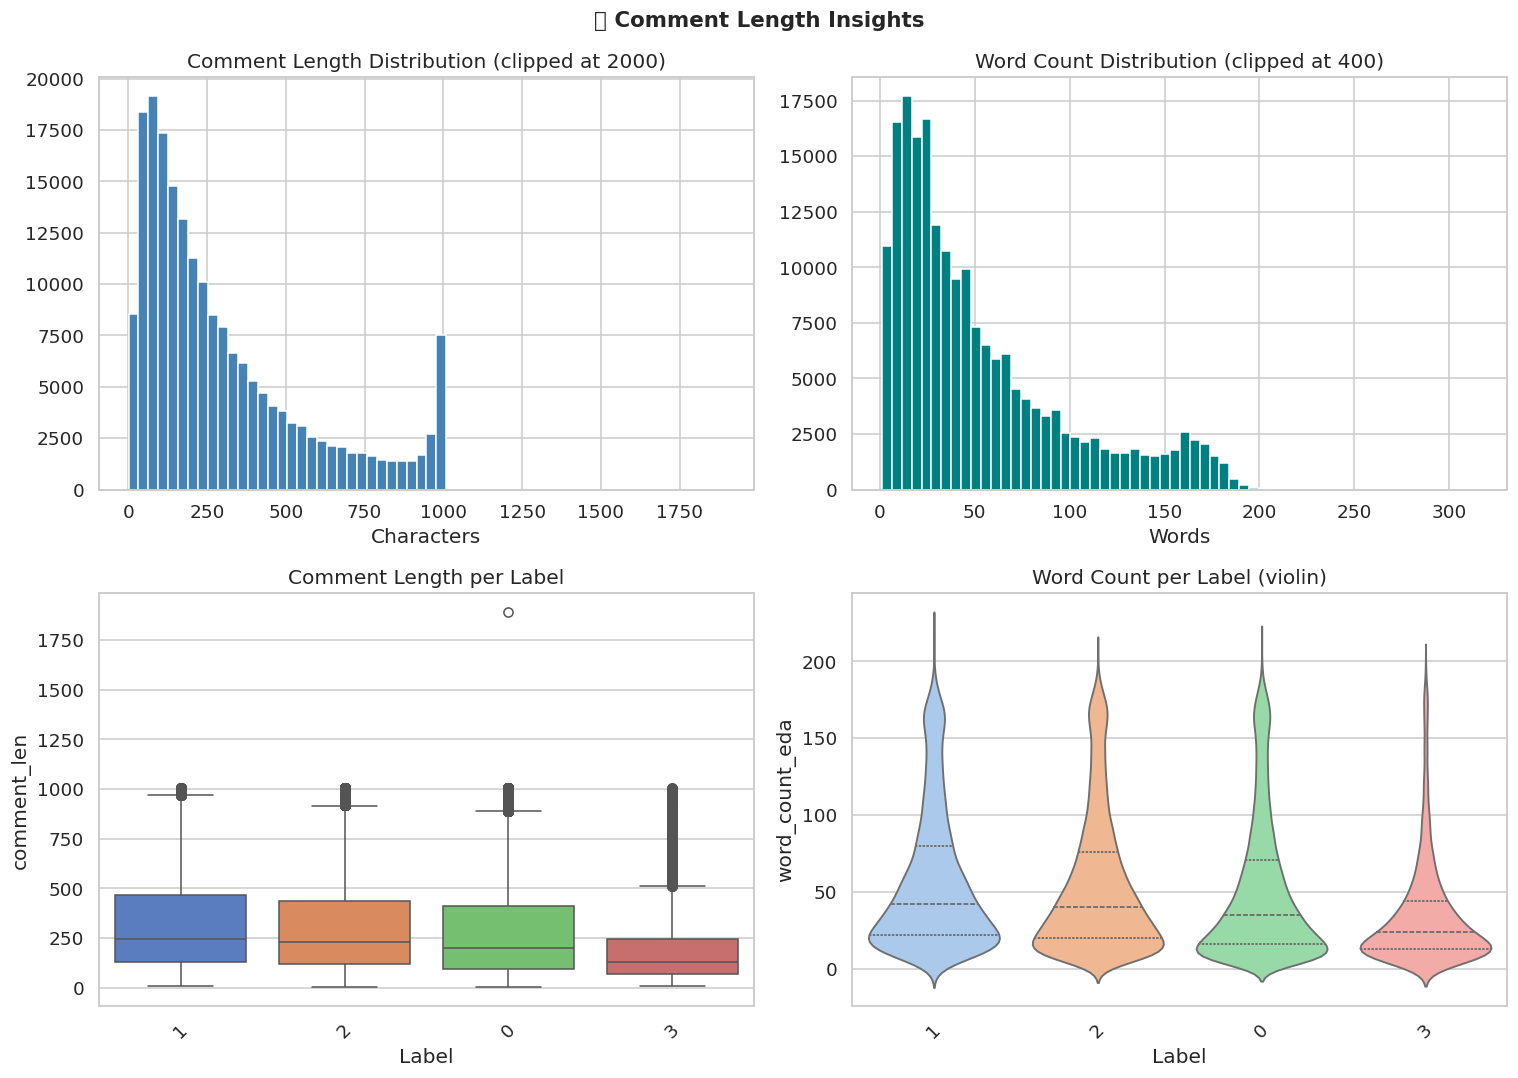

Mean comment length per label:
label
1    335.7
2    316.9
0    295.9
3    194.2
Name: comment_len, dtype: float64


In [8]:
# ============================================================
# 📌 CELL 6: COMMENT-LENGTH EDA
# ============================================================
# Insight: Longer comments may correlate with specific categories
# (e.g., hateful or toxic content tends to be verbose).

train['comment_len'] = train['comment'].astype(str).str.len()
train['word_count_eda'] = train['comment'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall comment length distribution
axes[0, 0].hist(train['comment_len'].clip(0, 2000), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Comment Length Distribution (clipped at 2000)')
axes[0, 0].set_xlabel('Characters')

# 2. Word count distribution
axes[0, 1].hist(train['word_count_eda'].clip(0, 400), bins=60, color='teal', edgecolor='white')
axes[0, 1].set_title('Word Count Distribution (clipped at 400)')
axes[0, 1].set_xlabel('Words')

# 3. Comment length vs label (boxplot)
order = train.groupby('label')['comment_len'].median().sort_values(ascending=False).index
sns.boxplot(
    x='label', y='comment_len',
    data=train[train['comment_len'] < 2000],
    order=order, ax=axes[1, 0],
    palette='muted'
)
axes[1, 0].set_title('Comment Length per Label')
axes[1, 0].set_xlabel('Label')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Word count vs label
sns.violinplot(
    x='label', y='word_count_eda',
    data=train[train['word_count_eda'] < 300],
    order=order, ax=axes[1, 1],
    palette='pastel', inner='quartile'
)
axes[1, 1].set_title('Word Count per Label (violin)')
axes[1, 1].set_xlabel('Label')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('📝 Comment Length Insights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean comment length per label:')
print(train.groupby('label')['comment_len'].mean().sort_values(ascending=False).round(1))

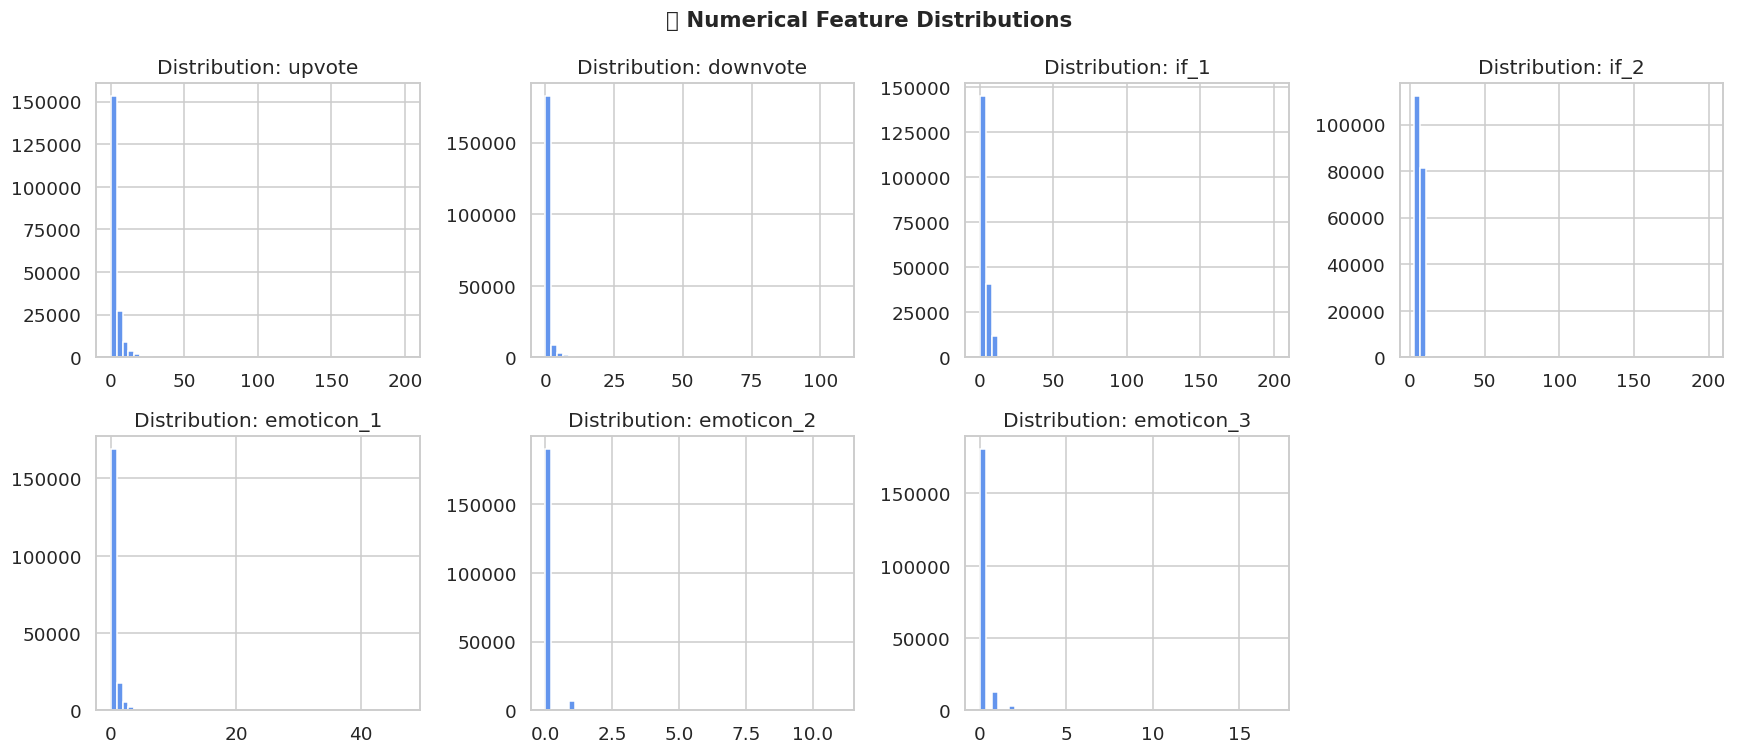

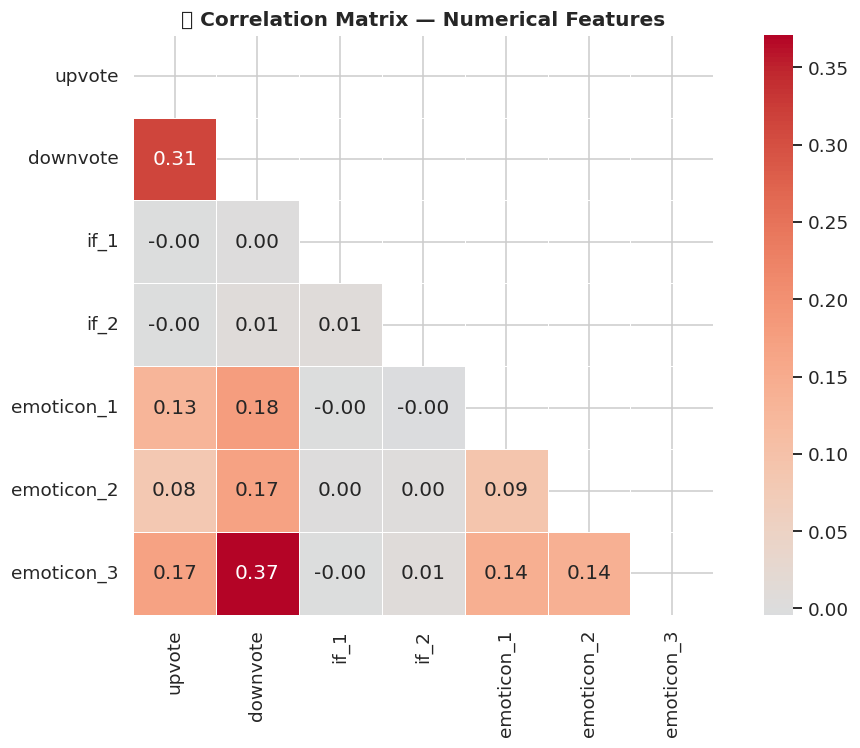

In [9]:
# ============================================================
# 📌 CELL 7: NUMERICAL FEATURE DISTRIBUTIONS & CORRELATIONS
# ============================================================
# Insight: Upvote/downvote patterns may signal community sentiment
# aligned with certain comment categories.

num_cols = ['upvote', 'downvote', 'if_1', 'if_2',
            'emoticon_1', 'emoticon_2', 'emoticon_3']
num_cols_present = [c for c in num_cols if c in train.columns]

# Distribution grid
n_cols = 4
n_rows = int(np.ceil(len(num_cols_present) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_present):
    axes[i].hist(train[col].dropna().clip(-10, 200), bins=50,
                 color='cornflowerblue', edgecolor='white')
    axes[i].set_title(f'Distribution: {col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📈 Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = [c for c in num_cols_present if train[c].notna().sum() > 0]
if corr_cols:
    corr = train[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, ax=ax,
        linewidths=0.5, square=True
    )
    ax.set_title('🔗 Correlation Matrix — Numerical Features', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# 📌 CELL 8: CATEGORICAL COLUMNS — CARDINALITY & ENCODING PLAN
# ============================================================
# Identify categorical columns and plan encoding:
#   - Binary flags  → make_binary_numeric (0/1)
#   - Low-cardinality categoricals → OrdinalEncoder inside Pipeline
#   - High-cardinality (e.g. post_id) → frequency encoding

cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()
# Exclude the target and the raw comment text
cat_cols_excl = [c for c in cat_cols if c not in ['label', 'comment', 'created_date']]

print(f'Categorical columns (excl. target/text/date): {cat_cols_excl}')
print()

for col in cat_cols_excl:
    n_unique = train[col].nunique()
    top_vals = train[col].value_counts().head(5).to_dict()
    print(f'  {col:25s} | unique={n_unique:5d} | top={top_vals}')

print()
print('📌 Encoding Strategy:')
print('  • Binary (True/False/Yes/No) columns → custom make_binary_numeric (→ int8)')
print('  • race, religion, gender, disability  → OrdinalEncoder in Pipeline')
print('  • post_id                             → frequency encoding')
print('  • created_date                        → datetime feature engineering')

Categorical columns (excl. target/text/date): ['race', 'religion', 'gender']

  race                      | unique=    6 | top={'none': 39682, 'white': 5486, 'black': 3869, 'other': 1654, 'asian': 1263}
  religion                  | unique=    8 | top={'none': 38249, 'christian': 7191, 'muslim': 4930, 'jewish': 1244, 'other': 547}
  gender                    | unique=    5 | top={'none': 36161, 'female': 8037, 'male': 7549, 'transgender': 622, 'other': 208}

📌 Encoding Strategy:
  • Binary (True/False/Yes/No) columns → custom make_binary_numeric (→ int8)
  • race, religion, gender, disability  → OrdinalEncoder in Pipeline
  • post_id                             → frequency encoding
  • created_date                        → datetime feature engineering


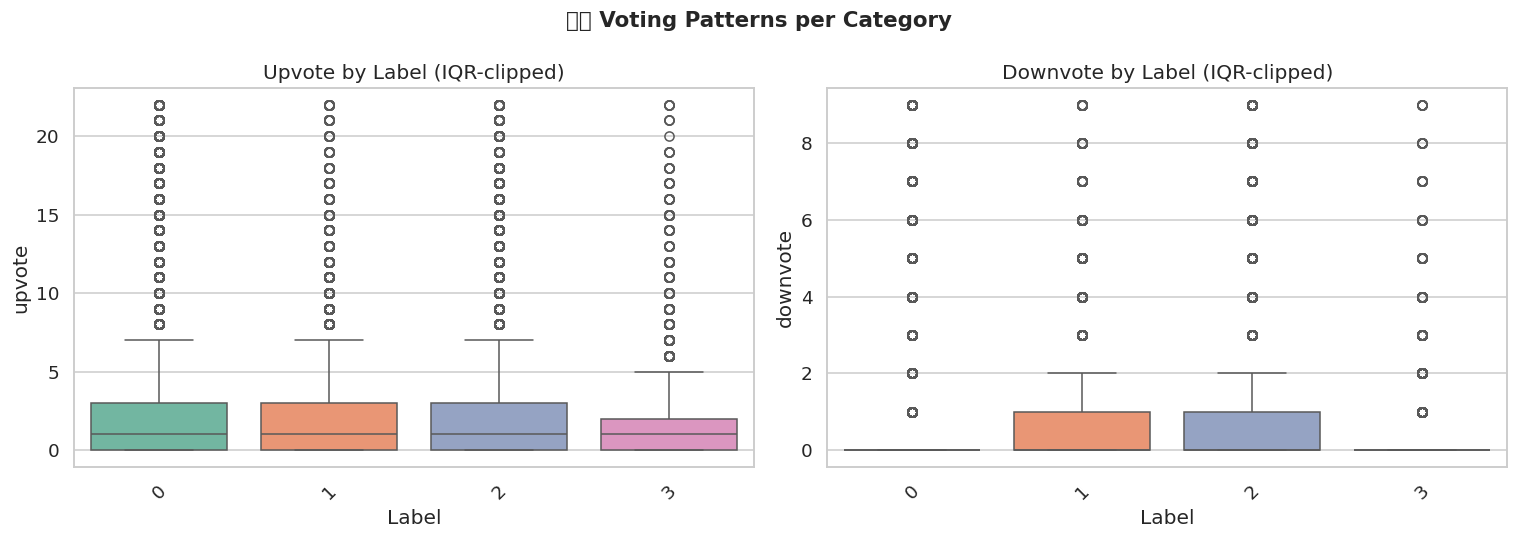

Median upvote per label:
label
0    1.0
1    1.0
2    1.0
3    1.0
Name: upvote, dtype: float64

Median downvote per label:
label
0    0.0
1    0.0
2    0.0
3    0.0
Name: downvote, dtype: float64


In [11]:
# ============================================================
# 📌 CELL 9: VOTING & ENGAGEMENT EDA
# ============================================================
# Insight: Vote patterns can reveal community reactions and may
# be strong predictors of comment toxicity or category.

vote_cols = [c for c in ['upvote', 'downvote'] if c in train.columns]

if vote_cols:
    fig, axes = plt.subplots(1, len(vote_cols), figsize=(7 * len(vote_cols), 5))
    if len(vote_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, vote_cols):
        sns.boxplot(
            x='label', y=col,
            data=train[train[col].between(train[col].quantile(0.01),
                                          train[col].quantile(0.99))],
            ax=ax, palette='Set2'
        )
        ax.set_title(f'{col.capitalize()} by Label (IQR-clipped)')
        ax.set_xlabel('Label')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle('👍👎 Voting Patterns per Category', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Vote summary stats per label
    print('Median upvote per label:')
    if 'upvote' in train.columns:
        print(train.groupby('label')['upvote'].median().sort_values(ascending=False))
    print()
    print('Median downvote per label:')
    if 'downvote' in train.columns:
        print(train.groupby('label')['downvote'].median().sort_values(ascending=False))

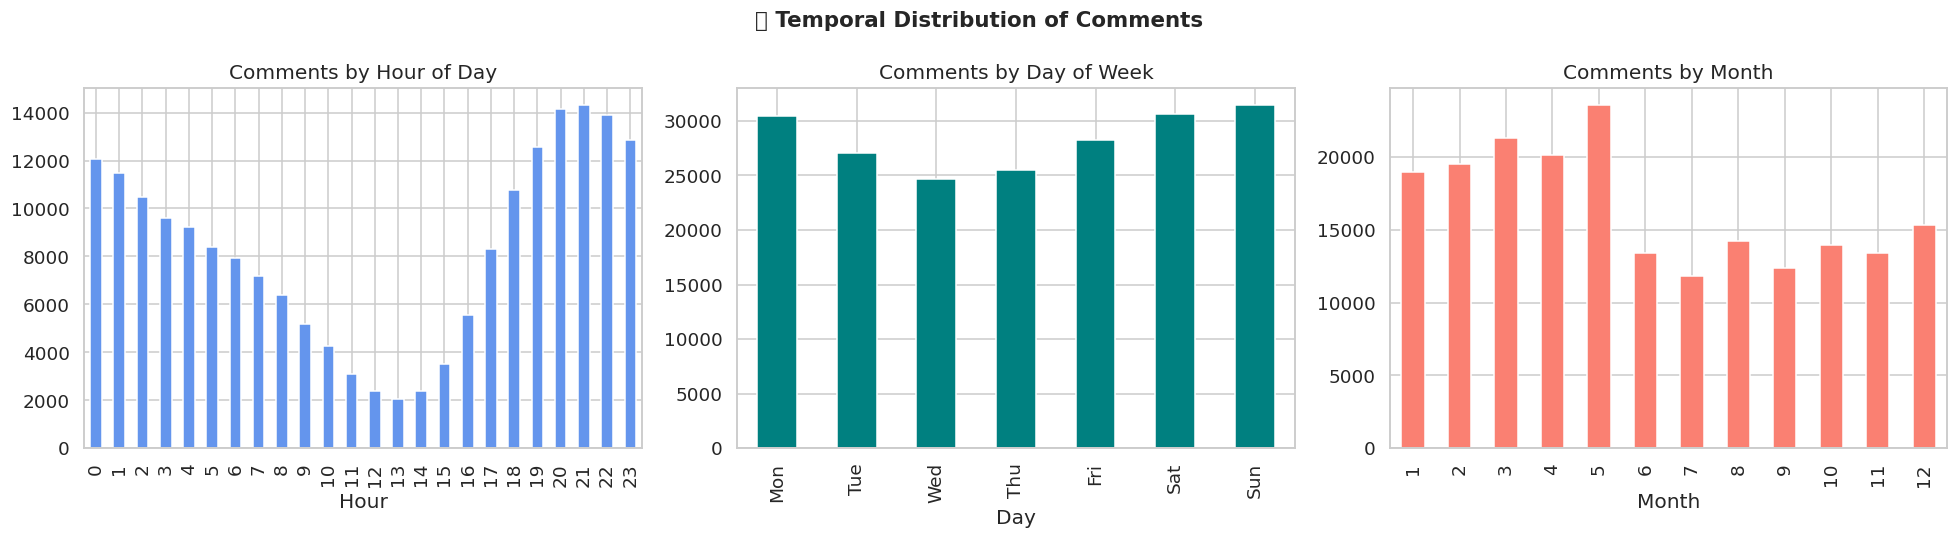

📌 Insight: Check if any hour / weekday has a disproportionate share of a specific category — it may be a useful feature.


In [12]:
# ============================================================
# 📌 CELL 10: TIME-SERIES EDA (created_date)
# ============================================================
# Insight: Comment posting patterns across hours/weekdays can
# reveal temporal trends tied to category types.

if 'created_date' in train.columns:
    dt_tmp = pd.to_datetime(train['created_date'], errors='coerce', utc=True)

    train['_hour']      = dt_tmp.dt.hour
    train['_dayofweek'] = dt_tmp.dt.dayofweek
    train['_month']     = dt_tmp.dt.month

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Hour of day
    train['_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
                                                    color='cornflowerblue')
    axes[0].set_title('Comments by Hour of Day')
    axes[0].set_xlabel('Hour')

    # Day of week
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    dow_counts = train['_dayofweek'].value_counts().sort_index()
    dow_counts.index = [day_labels[i] for i in dow_counts.index]
    dow_counts.plot(kind='bar', ax=axes[1], color='teal')
    axes[1].set_title('Comments by Day of Week')
    axes[1].set_xlabel('Day')

    # Month
    train['_month'].value_counts().sort_index().plot(kind='bar', ax=axes[2],
                                                     color='salmon')
    axes[2].set_title('Comments by Month')
    axes[2].set_xlabel('Month')

    plt.suptitle('🕐 Temporal Distribution of Comments', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Drop temp EDA columns
    train.drop(columns=['_hour', '_dayofweek', '_month'], inplace=True)

    print('📌 Insight: Check if any hour / weekday has a disproportionate share'
          ' of a specific category — it may be a useful feature.')

---
## ⚙️ Section 2 — Feature Engineering (with Pipelines)

In [13]:
# ============================================================
# 📌 CELL 11: TEXT CLEANING & BINARY ENCODING HELPERS
# ============================================================

def clean_text(x):
    """Normalise whitespace and strip special line-break chars."""
    x = '' if pd.isna(x) else str(x)
    x = x.replace('\n', ' ').replace('\r', ' ').strip()
    x = re.sub(r'\s+', ' ', x)
    return x


def make_binary_numeric(series):
    """
    Convert boolean / yes-no string columns to int8.
    Strategy: map known synonyms → numeric, coerce unknowns to 0.
    """
    return (
        series.replace({
            True: 1, False: 0,
            'True': 1, 'False': 0,
            'true': 1, 'false': 0,
            'YES': 1, 'NO': 0,
            'Yes': 1, 'No': 0,
            'yes': 1, 'no': 0
        })
        .pipe(pd.to_numeric, errors='coerce')
        .fillna(0)
        .astype('int8')
    )


print('✅ Helper functions defined.')

✅ Helper functions defined.


In [14]:
# ============================================================
# 📌 CELL 12: BASIC FEATURE ENGINEERING  (same logic as original)
# ============================================================
# This cell mirrors the original notebook's build_basic_features
# with the addition of:
#   - Explicit handling of NaN in all numeric operations
#   - Categorical columns (race, religion, gender, disability)
#     encoded via OrdinalEncoder INSIDE a sklearn Pipeline

# Categorical columns to encode with OrdinalEncoder
ORDINAL_COLS = ['race', 'religion', 'gender', 'disability']

# Pipeline for categorical imputation + encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   # fill NaN with mode
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,                                   # unseen at test time → -1
        encoded_missing_value=-1
    ))
])


def build_basic_features(df, cat_fit=None):
    """
    Build raw numerical and datetime features.

    Parameters
    ----------
    df      : pd.DataFrame  — raw train or test frame
    cat_fit : fitted cat_pipeline (None → fit on this df; pass fitted pipeline for test)

    Returns
    -------
    df_out  : enriched DataFrame
    cat_fit : fitted pipeline (to reuse on test set)
    """
    df = df.copy()

    # ── 1. Text cleaning ──────────────────────────────────────
    df['comment'] = df['comment'].fillna('').astype(str).map(clean_text)

    # ── 2. Datetime features ──────────────────────────────────
    dt = pd.to_datetime(df['created_date'], errors='coerce', utc=True)
    df['year']      = dt.dt.year.fillna(0).astype('int16')
    df['month']     = dt.dt.month.fillna(0).astype('int8')
    df['day']       = dt.dt.day.fillna(0).astype('int8')
    df['dayofweek'] = dt.dt.dayofweek.fillna(0).astype('int8')
    df['hour']      = dt.dt.hour.fillna(0).astype('int8')
    df['minute']    = dt.dt.minute.fillna(0).astype('int8')
    df['is_weekend']= (df['dayofweek'] >= 5).astype('int8')

    # Cyclical encoding of hour & day-of-week
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24).astype('float32')
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24).astype('float32')
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7).astype('float32')
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7).astype('float32')

    # ── 3. Text-derived numeric features ─────────────────────
    txt     = df['comment']
    txt_len = txt.str.len().replace(0, 1)  # avoid division by zero

    df['comment_len']        = txt.str.len().astype('int32')
    df['word_count']         = txt.str.split().str.len().fillna(0).astype('int32')
    df['unique_word_count']  = txt.apply(lambda s: len(set(s.split()))).astype('int32')
    df['char_count_no_space']= txt.str.replace(' ', '', regex=False).str.len().astype('int32')

    df['uppercase_count']    = txt.str.count(r'[A-Z]').fillna(0).astype('int32')
    df['lowercase_count']    = txt.str.count(r'[a-z]').fillna(0).astype('int32')
    df['digit_count']        = txt.str.count(r'\d').fillna(0).astype('int32')
    df['punct_count']        = txt.str.count(r'[^\w\s]').fillna(0).astype('int32')
    df['exclamation_count']  = txt.str.count(r'!').fillna(0).astype('int32')
    df['question_count']     = txt.str.count(r'\?').fillna(0).astype('int32')
    df['quote_count']        = txt.str.count(r'[\'\"\`]').fillna(0).astype('int32')
    df['url_count']          = txt.str.count(r'https?://').fillna(0).astype('int32')
    df['mention_count']      = txt.str.count(r'@\w+').fillna(0).astype('int32')
    df['has_url']            = (df['url_count'] > 0).astype('int8')

    df['uppercase_ratio']    = (df['uppercase_count'] / txt_len).fillna(0).astype('float32')
    df['digit_ratio']        = (df['digit_count']    / txt_len).fillna(0).astype('float32')
    df['punct_ratio']        = (df['punct_count']    / txt_len).fillna(0).astype('float32')
    df['space_ratio']        = (txt.str.count(r' ')  / txt_len).fillna(0).astype('float32')

    words        = txt.str.split()
    word_lens    = words.apply(lambda ws: np.mean([len(w) for w in ws]) if ws else 0)
    df['avg_word_len']       = word_lens.fillna(0).astype('float32')
    df['lexical_diversity']  = (
        df['unique_word_count'] / df['word_count'].replace(0, 1)
    ).fillna(0).astype('float32')
    df['starts_with_capital']= txt.str.match(r'^[A-Z]').astype('int8')
    df['ends_with_punct']    = txt.str.match(r'.*[.!?]$').astype('int8')

    # ── 4. Vote / engagement features ────────────────────────
    upvote   = df['upvote'].fillna(0)
    downvote = df['downvote'].fillna(0)
    df['vote_sum']       = (upvote + downvote).astype('float32')
    df['vote_diff']      = (upvote - downvote).astype('float32')
    df['vote_ratio']     = (upvote / (downvote + 1)).astype('float32')
    df['downvote_ratio'] = (downvote / (df['vote_sum'] + 1)).astype('float32')
    df['engagement_log'] = np.log1p(df['vote_sum']).astype('float32')

    # ── 5. Aggregated identity / emoticon sums ────────────────
    identity_cols = ['race', 'religion', 'gender', 'disability', 'if_1', 'if_2']
    emoticon_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3']

    # Convert boolean / text flags to numeric BEFORE summing
    for c in identity_cols + emoticon_cols:
        if c in df.columns:
            df[c] = make_binary_numeric(df[c])

    id_present   = [c for c in ['if_1', 'if_2'] if c in df.columns]
    emot_present = [c for c in emoticon_cols if c in df.columns]

    df['identity_sum'] = df[id_present].sum(axis=1).astype('int16')  if id_present   else 0
    df['emoticon_sum'] = df[emot_present].sum(axis=1).astype('int16') if emot_present else 0

    # ── 6. Categorical encoding via Pipeline ─────────────────
    ord_present = [c for c in ORDINAL_COLS if c in df.columns]
    if ord_present:
        if cat_fit is None:
            # Fit only on training data to prevent data leakage
            cat_fit = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(
                    handle_unknown='use_encoded_value',
                    unknown_value=-1,
                    encoded_missing_value=-1
                ))
            ])
            encoded = cat_fit.fit_transform(df[ord_present])
        else:
            encoded = cat_fit.transform(df[ord_present])

        df[ord_present] = encoded.astype('float32')

    return df, cat_fit


print('✅ build_basic_features defined (with Pipeline-based categorical encoding).')

✅ build_basic_features defined (with Pipeline-based categorical encoding).


In [15]:
# ============================================================
# 📌 CELL 13: GROUP & FREQUENCY FEATURES  (same as original)
# ============================================================

def add_group_features(train_df, test_df):
    """Add post-level aggregation features (no leakage — computed over full data)."""
    train_df = train_df.copy()
    test_df  = test_df.copy()

    full = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    post_agg = full.groupby('post_id').agg(
        post_comment_count    = ('comment', 'size'),
        post_upvote_mean      = ('upvote', 'mean'),
        post_upvote_std       = ('upvote', 'std'),
        post_downvote_mean    = ('downvote', 'mean'),
        post_vote_sum_mean    = ('vote_sum', 'mean'),
        post_vote_diff_mean   = ('vote_diff', 'mean'),
        post_comment_len_mean = ('comment_len', 'mean'),
        post_word_count_mean  = ('word_count', 'mean'),
        post_identity_sum_mean= ('identity_sum', 'mean'),
        post_emoticon_sum_mean= ('emoticon_sum', 'mean'),
        post_if1_mean         = ('if_1', 'mean'),
        post_if2_mean         = ('if_2', 'mean'),
    ).reset_index()

    for col in post_agg.columns:
        if col != 'post_id':
            post_agg[col] = post_agg[col].fillna(0)

    train_df = train_df.merge(post_agg, on='post_id', how='left')
    test_df  = test_df.merge(post_agg, on='post_id', how='left')

    rel_cols = [
        ('upvote',       'post_upvote_mean',       'upvote_vs_post_mean'),
        ('downvote',     'post_downvote_mean',      'downvote_vs_post_mean'),
        ('vote_sum',     'post_vote_sum_mean',      'vote_sum_vs_post_mean'),
        ('vote_diff',    'post_vote_diff_mean',     'vote_diff_vs_post_mean'),
        ('comment_len',  'post_comment_len_mean',   'comment_len_vs_post_mean'),
        ('word_count',   'post_word_count_mean',    'word_count_vs_post_mean'),
        ('identity_sum', 'post_identity_sum_mean',  'identity_sum_vs_post_mean'),
        ('emoticon_sum', 'post_emoticon_sum_mean',  'emoticon_sum_vs_post_mean'),
        ('if_1',         'post_if1_mean',           'if1_vs_post_mean'),
        ('if_2',         'post_if2_mean',            'if2_vs_post_mean'),
    ]

    for raw_col, mean_col, new_col in rel_cols:
        if raw_col in train_df.columns and mean_col in train_df.columns:
            train_df[new_col] = (
                (train_df[raw_col] - train_df[mean_col])
                / (train_df[mean_col].abs() + 1e-6)
            ).astype('float32')
            test_df[new_col] = (
                (test_df[raw_col] - test_df[mean_col])
                / (test_df[mean_col].abs() + 1e-6)
            ).astype('float32')

    return train_df, test_df


def add_frequency_features(train_df, test_df, cols):
    """Encode each column as its frequency in the combined dataset."""
    train_df = train_df.copy()
    test_df  = test_df.copy()

    full = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    for col in cols:
        if col not in full.columns:
            continue
        freq_map = full[col].value_counts(normalize=True).to_dict()
        new_col  = f'{col}_freq'
        train_df[new_col] = train_df[col].map(freq_map).fillna(0).astype('float32')
        test_df[new_col]  = test_df[col].map(freq_map).fillna(0).astype('float32')

    return train_df, test_df


print('✅ Group & frequency feature functions defined.')

✅ Group & frequency feature functions defined.


In [16]:
# ============================================================
# 📌 CELL 14: TEXT FEATURE BUILDERS  (same as original)
# ============================================================

def build_text_matrices(train_text, test_text):
    """TF-IDF word + char n-gram matrices, concatenated."""
    word_vec = TfidfVectorizer(
        lowercase=True, strip_accents='unicode',
        analyzer='word', ngram_range=(1, 2),
        min_df=3, max_df=0.98, max_features=60000,
        sublinear_tf=True
    )
    char_vec = TfidfVectorizer(
        lowercase=True, strip_accents='unicode',
        analyzer='char_wb', ngram_range=(3, 5),
        min_df=3, max_features=40000,
        sublinear_tf=True
    )

    Xw_train = word_vec.fit_transform(train_text)
    Xw_test  = word_vec.transform(test_text)
    Xc_train = char_vec.fit_transform(train_text)
    Xc_test  = char_vec.transform(test_text)

    X_text_train = hstack([Xw_train, Xc_train]).tocsr()
    X_text_test  = hstack([Xw_test, Xc_test]).tocsr()
    return X_text_train, X_text_test


def build_svd_features(X_text_train, X_text_test, n_components=SVD_COMPONENTS):
    """
    Reduce TF-IDF matrices to dense SVD (LSA) features.
    n_components is controlled by SVD_COMPONENTS in config (default 100).
    Lower value = much faster HPT; increase to 256 for final production runs.
    """
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    Xs_train = svd.fit_transform(X_text_train).astype(np.float32)
    Xs_test  = svd.transform(X_text_test).astype(np.float32)
    print(f'  SVD variance explained: {svd.explained_variance_ratio_.sum():.3f}')
    return Xs_train, Xs_test


def build_oof_lr_features(X_text_train, y, X_text_test):
    """
    Out-of-fold Logistic Regression predictions as meta-features.
    Prevents target leakage from LR into downstream models.
    """
    skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    n_classes = len(np.unique(y))

    oof_lr  = np.zeros((X_text_train.shape[0], n_classes), dtype=np.float32)
    test_lr = np.zeros((X_text_test.shape[0],  n_classes), dtype=np.float32)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_text_train, y), 1):
        X_tr, X_va = X_text_train[tr_idx], X_text_train[va_idx]
        y_tr       = y[tr_idx]

        lr = LogisticRegression(
            C=4.0, max_iter=3000, solver='saga',
            multi_class='multinomial', n_jobs=-1,
            random_state=SEED + fold
        )
        lr.fit(X_tr, y_tr)

        oof_lr[va_idx] = lr.predict_proba(X_va)
        test_lr       += lr.predict_proba(X_text_test) / N_SPLITS

        print(f'  LR fold {fold} done')

    return oof_lr, test_lr


print('✅ Text feature builder functions defined.')


✅ Text feature builder functions defined.


In [17]:
# ============================================================
# 📌 CELL 15: RUN FULL DATA PREPARATION PIPELINE
# ============================================================
# Steps:
#   1. Build basic + datetime + text-stat features (via Pipeline encoder)
#   2. Add group aggregation features
#   3. Add frequency-encoding features
#   4. Build TF-IDF text matrices
#   5. Build SVD + OOF-LR meta features
#   6. Assemble final feature matrix

# 1. Basic features (cat_fit fitted on train, applied to test)
train, cat_fit = build_basic_features(train, cat_fit=None)
test,  _       = build_basic_features(test,  cat_fit=cat_fit)

# 2. Group features
train, test = add_group_features(train, test)

# 3. Frequency features
train, test = add_frequency_features(
    train, test,
    cols=['post_id', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability']
)

# 4. Text columns
text_train = train['comment'].astype(str)
text_test  = test['comment'].astype(str)

# 5. Label encode target
le = LabelEncoder()
y  = le.fit_transform(train['label'])
print(f'Classes ({len(le.classes_)}): {list(le.classes_)}')

# 6. Text matrices
print('\n--- Building TF-IDF matrices ---')
X_text_train, X_text_test = build_text_matrices(text_train, text_test)
print(f'TF-IDF train: {X_text_train.shape}, test: {X_text_test.shape}')

print(f'\n--- Building SVD features (n_components={SVD_COMPONENTS}) ---')
X_svd_train, X_svd_test = build_svd_features(X_text_train, X_text_test, SVD_COMPONENTS)

print('\n--- Building OOF LR meta-features ---')
X_lr_oof_train, X_lr_test = build_oof_lr_features(X_text_train, y, X_text_test)


Classes (4): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

--- Building TF-IDF matrices ---
TF-IDF train: (198000, 100000), test: (102000, 100000)

--- Building SVD features (n_components=100) ---
  SVD variance explained: 0.093

--- Building OOF LR meta-features ---
  LR fold 1 done
  LR fold 2 done
  LR fold 3 done
  LR fold 4 done
  LR fold 5 done


In [18]:
# ============================================================
# 📌 CELL 16: ASSEMBLE NUMERICAL FEATURE MATRIX
# ============================================================

FEATURE_COLS = [
    # --- IDs & binary flags ---
    'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',

    # --- Encoded categoricals ---
    'race', 'religion', 'gender', 'disability',

    # --- Datetime features ---
    'year', 'month', 'day', 'dayofweek', 'hour', 'minute', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',

    # --- Text statistics ---
    'comment_len', 'word_count', 'unique_word_count', 'char_count_no_space',
    'uppercase_count', 'lowercase_count', 'digit_count', 'punct_count',
    'exclamation_count', 'question_count', 'quote_count', 'url_count', 'mention_count',
    'has_url', 'uppercase_ratio', 'digit_ratio', 'punct_ratio', 'space_ratio',
    'avg_word_len', 'lexical_diversity', 'starts_with_capital', 'ends_with_punct',

    # --- Engagement features ---
    'vote_sum', 'vote_diff', 'vote_ratio', 'downvote_ratio', 'engagement_log',
    'emoticon_sum', 'identity_sum',

    # --- Post-level aggregates ---
    'post_comment_count', 'post_upvote_mean', 'post_upvote_std',
    'post_downvote_mean', 'post_vote_sum_mean', 'post_vote_diff_mean',
    'post_comment_len_mean', 'post_word_count_mean', 'post_identity_sum_mean',
    'post_emoticon_sum_mean', 'post_if1_mean', 'post_if2_mean',

    # --- Relative to post-mean ---
    'upvote_vs_post_mean', 'downvote_vs_post_mean', 'vote_sum_vs_post_mean',
    'vote_diff_vs_post_mean', 'comment_len_vs_post_mean', 'word_count_vs_post_mean',
    'identity_sum_vs_post_mean', 'emoticon_sum_vs_post_mean',
    'if1_vs_post_mean', 'if2_vs_post_mean',

    # --- Frequency encodings ---
    'post_id_freq', 'if_1_freq', 'if_2_freq',
    'race_freq', 'religion_freq', 'gender_freq', 'disability_freq'
]

# Only keep columns that actually exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]

# Impute any remaining NaNs (safety net) and cast to float32
num_imputer = SimpleImputer(strategy='constant', fill_value=0)
X_num_train = num_imputer.fit_transform(train[FEATURE_COLS]).astype(np.float32)
X_num_test  = num_imputer.transform(test[FEATURE_COLS]).astype(np.float32)

# Stack: numerical + SVD text + LR meta-features
X_train = np.hstack([X_num_train, X_svd_train, X_lr_oof_train]).astype(np.float32)
X_test  = np.hstack([X_num_test,  X_svd_test,  X_lr_test]).astype(np.float32)

print(f'Final X_train: {X_train.shape}')
print(f'Final X_test : {X_test.shape}')

Final X_train: (198000, 185)
Final X_test : (102000, 185)


---
## 🤖 Section 3 — Model Training with Hyperparameter Tuning

In [19]:
# ============================================================
# 📌 CELL 17: LIGHTGBM — HYPERPARAMETER TUNING
# ============================================================
# Strategy to avoid the "stuck at 60 fits" problem:
#   • HPT_SUBSAMPLE=10% → much smaller matrix fed to RandomizedSearchCV
#   • N_ITER_HPT=8      → 8 × 3 = 24 fits total (was 60)
#   • n_estimators capped at 300 during HPT (early-stopping used in full training)
#   • n_jobs=1 for the search (LightGBM parallelises internally via n_jobs=-1)

from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split

print('🔎 LightGBM — Randomized Hyperparameter Search ...')
print(f'   Subsample: {HPT_SUBSAMPLE*100:.0f}% of training data')
print(f'   Candidates: {N_ITER_HPT} × 3 folds = {N_ITER_HPT*3} fits')

# ---- Small subsample for HPT (avoids slow dense-matrix CV on full data) ----
X_hpt, _, y_hpt, _ = train_test_split(
    X_train, y,
    test_size=1.0 - HPT_SUBSAMPLE,
    stratify=y, random_state=SEED
)
print(f'   HPT matrix shape: {X_hpt.shape}')

lgb_param_dist = {
    'num_leaves'        : randint(64, 200),
    'learning_rate'     : uniform(0.03, 0.12),
    'n_estimators'      : randint(100, 300),   # capped — early stopping handles the rest
    'min_child_samples' : randint(10, 40),
    'subsample'         : uniform(0.6, 0.35),
    'colsample_bytree'  : uniform(0.5, 0.45),
    'reg_alpha'         : uniform(0.0, 0.4),
    'reg_lambda'        : uniform(0.5, 2.5),
}

lgb_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    random_state=SEED,
    n_jobs=-1,           # LightGBM uses all cores per model
    force_col_wise=True,
    verbosity=-1
)

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_param_dist,
    n_iter=N_ITER_HPT,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=1,            # IMPORTANT: outer loop single-threaded (LGB already parallel)
    random_state=SEED,
    verbose=2            # verbose=2 shows each fold completing — confirms it's not frozen
)
lgb_search.fit(X_hpt, y_hpt)

best_lgb_params = lgb_search.best_params_
print(f'\n✅ Best LightGBM params (HPT):  {best_lgb_params}')
print(f'   Best CV accuracy (subsample): {lgb_search.best_score_:.4f}')


🔎 LightGBM — Randomized Hyperparameter Search ...
   Subsample: 10% of training data
   Candidates: 8 × 3 folds = 24 fits
   HPT matrix shape: (19800, 185)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=0.6685430534813132, learning_rate=0.14408571676918994, min_child_samples=20, n_estimators=171, num_leaves=84, reg_alpha=0.06240745617697461, reg_lambda=0.8899863008405067, subsample=0.6203292642588698; total time=  11.2s
[CV] END colsample_bytree=0.6685430534813132, learning_rate=0.14408571676918994, min_child_samples=20, n_estimators=171, num_leaves=84, reg_alpha=0.06240745617697461, reg_lambda=0.8899863008405067, subsample=0.6203292642588698; total time=  11.3s
[CV] END colsample_bytree=0.6685430534813132, learning_rate=0.14408571676918994, min_child_samples=20, n_estimators=171, num_leaves=84, reg_alpha=0.06240745617697461, reg_lambda=0.8899863008405067, subsample=0.6203292642588698; total time=  11.1s
[CV] END colsample_bytree=0.889779265598720

In [20]:
# ============================================================
# 📌 CELL 18: LIGHTGBM — FULL STRATIFIED K-FOLD TRAINING
# ============================================================
# Uses the best params from HPT, keeps early-stopping identical
# to the original notebook (250 rounds patience).

def train_lgbm(X_train, X_test, y, best_params=None):
    """
    Train LightGBM with StratifiedKFold CV.
    Merges best_params from HPT with the original fixed defaults.
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    n_classes = len(np.unique(y))

    oof_pred   = np.zeros((len(X_train), n_classes), dtype=np.float32)
    test_pred  = np.zeros((len(X_test),  n_classes), dtype=np.float32)
    fold_scores = []

    # Merge HPT params with fixed params (HPT wins on overlapping keys)
    fixed_params = dict(
        objective='multiclass', num_class=n_classes,
        learning_rate=0.02, n_estimators=5000,
        num_leaves=255, max_depth=-1,
        min_child_samples=20, subsample=0.85, subsample_freq=1,
        colsample_bytree=0.75, reg_alpha=0.2, reg_lambda=2.0,
        n_jobs=-1, force_col_wise=True, verbosity=-1
    )
    if best_params:
        fixed_params.update(best_params)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y), 1):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = lgb.LGBMClassifier(random_state=SEED + fold, **fixed_params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric='multi_logloss',
            callbacks=[
                lgb.early_stopping(250, verbose=False),
                lgb.log_evaluation(200)
            ]
        )

        oof_pred[va_idx]  = model.predict_proba(X_va)
        test_pred        += model.predict_proba(X_test) / N_SPLITS

        fold_acc = accuracy_score(y_va, np.argmax(oof_pred[va_idx], axis=1))
        fold_scores.append(fold_acc)
        print(f'  Fold {fold} accuracy: {fold_acc:.6f}')

        del model, X_tr, X_va, y_tr, y_va
        gc.collect()

    cv_acc = accuracy_score(y, np.argmax(oof_pred, axis=1))
    print(f'\n===== LGBM RESULTS =====')
    print(f'Overall CV accuracy  : {cv_acc:.6f}')
    print(f'Fold accuracies      : {[round(x, 6) for x in fold_scores]}')

    return cv_acc, test_pred, oof_pred


lgb_acc, lgb_test, lgb_oof = train_lgbm(X_train, X_test, y, best_params=best_lgb_params)

[200]	valid_0's multi_logloss: 0.267218
  Fold 1 accuracy: 0.912399
[200]	valid_0's multi_logloss: 0.260507
  Fold 2 accuracy: 0.914975
[200]	valid_0's multi_logloss: 0.259903
  Fold 3 accuracy: 0.913586
[200]	valid_0's multi_logloss: 0.263192
  Fold 4 accuracy: 0.915025
[200]	valid_0's multi_logloss: 0.257838
  Fold 5 accuracy: 0.915707

===== LGBM RESULTS =====
Overall CV accuracy  : 0.914338
Fold accuracies      : [0.912399, 0.914975, 0.913586, 0.915025, 0.915707]


In [21]:
# ============================================================
# 📌 CELL 19: RANDOM FOREST — HYPERPARAMETER TUNING
# ============================================================
# Uses the SAME 10% subsample already built (X_hpt, y_hpt).
# n_estimators capped at 150 for HPT; full training uses best params.

print('🔎 Random Forest — Randomized Hyperparameter Search ...')
print(f'   HPT matrix shape: {X_hpt.shape}')
print(f'   Candidates: {N_ITER_HPT} × 3 folds = {N_ITER_HPT*3} fits')

rf_param_dist = {
    'n_estimators'      : randint(50, 150),    # capped for HPT speed
    'max_depth'         : [10, 20, 30, None],
    'min_samples_split' : randint(2, 15),
    'min_samples_leaf'  : randint(1, 8),
    'max_features'      : ['sqrt', 'log2', 0.3],
    'class_weight'      : [None, 'balanced'],
}

rf_base = RandomForestClassifier(n_jobs=-1, random_state=SEED)

rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=N_ITER_HPT,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=-1,
    random_state=SEED,
    verbose=2
)
rf_search.fit(X_hpt, y_hpt)

best_rf_params = rf_search.best_params_
print(f'\n✅ Best RF params (HPT):  {best_rf_params}')
print(f'   Best CV accuracy (subsample): {rf_search.best_score_:.4f}')


🔎 Random Forest — Randomized Hyperparameter Search ...
   HPT matrix shape: (19800, 185)
   Candidates: 8 × 3 folds = 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best RF params (HPT):  {'class_weight': None, 'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 136}
   Best CV accuracy (subsample): 0.9138


In [22]:
# ============================================================
# 📌 CELL 20: RANDOM FOREST — FULL STRATIFIED K-FOLD TRAINING
# ============================================================

def train_rf(X_train, X_test, y, best_params=None):
    """Train Random Forest with StratifiedKFold CV using HPT params."""
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    n_classes = len(np.unique(y))

    oof_pred  = np.zeros((len(X_train), n_classes), dtype=np.float32)
    test_pred = np.zeros((len(X_test),  n_classes), dtype=np.float32)
    fold_scores = []

    default_params = dict(n_estimators=200, max_depth=20)
    if best_params:
        default_params.update(best_params)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y), 1):
        model = RandomForestClassifier(
            random_state=SEED, n_jobs=-1, **default_params
        )
        model.fit(X_train[tr_idx], y[tr_idx])

        oof_pred[va_idx]  = model.predict_proba(X_train[va_idx])
        test_pred        += model.predict_proba(X_test) / N_SPLITS

        fold_acc = accuracy_score(y[va_idx], np.argmax(oof_pred[va_idx], axis=1))
        fold_scores.append(fold_acc)
        print(f'  RF Fold {fold} accuracy: {fold_acc:.6f}')

        del model
        gc.collect()

    acc = accuracy_score(y, np.argmax(oof_pred, axis=1))
    print(f'\n===== RANDOM FOREST RESULTS =====')
    print(f'Overall CV accuracy  : {acc:.6f}')
    print(f'Fold accuracies      : {[round(x, 6) for x in fold_scores]}')

    return acc, test_pred, oof_pred


rf_acc, rf_test, rf_oof = train_rf(X_train, X_test, y, best_params=best_rf_params)

[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=7, min_samples_split=12, n_estimators=121; total time=  31.7s
[CV] END class_weight=None, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=4, n_estimators=136; total time= 1.9min
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=12, n_estimators=108; total time=  21.9s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=12, n_estimators=108; total time=  21.4s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=3, min_samples_split=6, n_estimators=100; total time=  27.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=3, min_samples_split=6, n_estimators=100; total time=  27.0s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=3, min_samples_split=6, n_estimators=100; total time=  27.

In [23]:
# ============================================================
# 📌 CELL 21: NAIVE BAYES — HYPERPARAMETER TUNING
# ============================================================
# NB works on the SPARSE TF-IDF matrix (non-negative), not X_train.
# Uses same HPT_SUBSAMPLE fraction from the sparse matrix.

from sklearn.model_selection import train_test_split as tts_sparse

print('🔎 Naive Bayes — Hyperparameter Search ...')
print(f'   Subsample: {HPT_SUBSAMPLE*100:.0f}% of TF-IDF matrix')
print(f'   Candidates per variant: {N_ITER_HPT} × 3 folds = {N_ITER_HPT*3} fits')

# Small subsample of the sparse TF-IDF matrix
X_hpt_nb, _, y_hpt_nb, _ = tts_sparse(
    X_text_train, y,
    test_size=1.0 - HPT_SUBSAMPLE,
    stratify=y, random_state=SEED
)
print(f'   NB HPT matrix shape: {X_hpt_nb.shape}')

# --- MultinomialNB ---
mnb_param_dist = {'alpha': uniform(0.01, 2.0)}
mnb_search = RandomizedSearchCV(
    MultinomialNB(), mnb_param_dist,
    n_iter=N_ITER_HPT,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, random_state=SEED, verbose=0
)
mnb_search.fit(X_hpt_nb, y_hpt_nb)
print(f'  MultinomialNB  best alpha={mnb_search.best_params_["alpha"]:.3f}  '
      f'acc={mnb_search.best_score_:.4f}')

# --- ComplementNB ---
cnb_param_dist = {'alpha': uniform(0.01, 2.0), 'norm': [True, False]}
cnb_search = RandomizedSearchCV(
    ComplementNB(), cnb_param_dist,
    n_iter=N_ITER_HPT,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, random_state=SEED, verbose=0
)
cnb_search.fit(X_hpt_nb, y_hpt_nb)
print(f'  ComplementNB   best alpha={cnb_search.best_params_["alpha"]:.3f}  '
      f'acc={cnb_search.best_score_:.4f}')

# Pick the better variant automatically
if mnb_search.best_score_ >= cnb_search.best_score_:
    best_nb_model = mnb_search.best_estimator_
    best_nb_name  = 'MultinomialNB'
else:
    best_nb_model = cnb_search.best_estimator_
    best_nb_name  = 'ComplementNB'

print(f'\n✅ Best NB variant: {best_nb_name}')


🔎 Naive Bayes — Hyperparameter Search ...
   Subsample: 10% of TF-IDF matrix
   Candidates per variant: 8 × 3 folds = 24 fits
   NB HPT matrix shape: (19800, 100000)
  MultinomialNB  best alpha=0.126  acc=0.7089
  ComplementNB   best alpha=0.377  acc=0.7073

✅ Best NB variant: MultinomialNB


In [24]:
# ============================================================
# 📌 CELL 22: NAIVE BAYES — FULL STRATIFIED K-FOLD TRAINING
# ============================================================

def train_nb(X_text_train, X_text_test, y, nb_model):
    """Train the tuned Naive Bayes model with StratifiedKFold CV."""
    from sklearn.base import clone

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    n_classes = len(np.unique(y))

    oof_pred  = np.zeros((X_text_train.shape[0], n_classes), dtype=np.float32)
    test_pred = np.zeros((X_text_test.shape[0],  n_classes), dtype=np.float32)
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_text_train, y), 1):
        model = clone(nb_model)
        model.fit(X_text_train[tr_idx], y[tr_idx])

        oof_pred[va_idx]  = model.predict_proba(X_text_train[va_idx])
        test_pred        += model.predict_proba(X_text_test) / N_SPLITS

        fold_acc = accuracy_score(y[va_idx], np.argmax(oof_pred[va_idx], axis=1))
        fold_scores.append(fold_acc)
        print(f'  NB Fold {fold} accuracy: {fold_acc:.6f}')

    acc = accuracy_score(y, np.argmax(oof_pred, axis=1))
    print(f'\n===== NAIVE BAYES RESULTS =====')
    print(f'Overall CV accuracy  : {acc:.6f}')
    print(f'Fold accuracies      : {[round(x, 6) for x in fold_scores]}')

    return acc, test_pred, oof_pred


nb_acc, nb_test, nb_oof = train_nb(X_text_train, X_text_test, y, best_nb_model)

  NB Fold 1 accuracy: 0.726414
  NB Fold 2 accuracy: 0.729697
  NB Fold 3 accuracy: 0.731717
  NB Fold 4 accuracy: 0.729773
  NB Fold 5 accuracy: 0.732475

===== NAIVE BAYES RESULTS =====
Overall CV accuracy  : 0.730015
Fold accuracies      : [0.726414, 0.729697, 0.731717, 0.729773, 0.732475]


---
## 📊 Section 4 — Model Comparison & Insights


       FINAL MODEL COMPARISON
  LightGBM     : 0.914338
  RandomForest : 0.913909
  Naive Bayes  : 0.730015  (MultinomialNB)


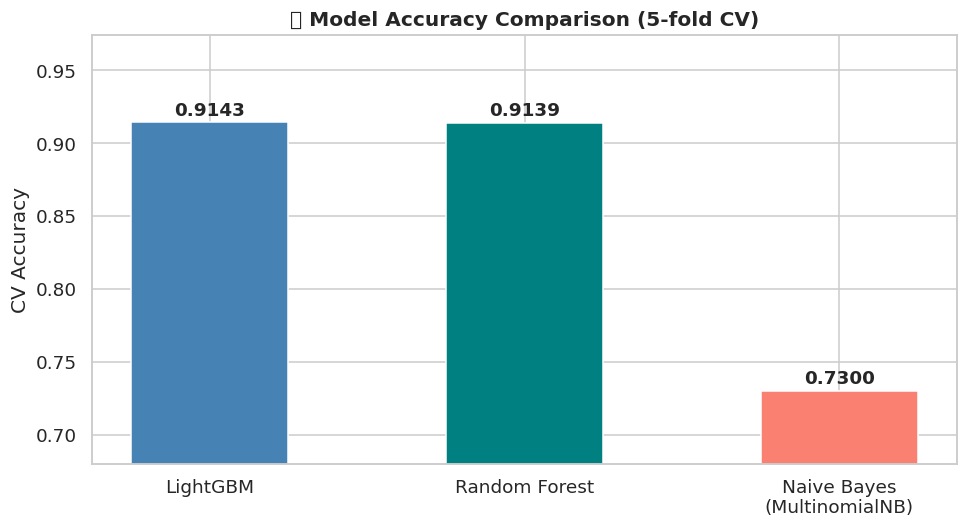

In [25]:
# ============================================================
# 📌 CELL 23: MODEL COMPARISON — ACCURACY SUMMARY
# ============================================================

print('\n' + '=' * 50)
print('       FINAL MODEL COMPARISON')
print('=' * 50)
print(f'  LightGBM     : {lgb_acc:.6f}')
print(f'  RandomForest : {rf_acc:.6f}')
print(f'  Naive Bayes  : {nb_acc:.6f}  ({best_nb_name})')
print('=' * 50)

models = ['LightGBM', 'Random Forest', f'Naive Bayes\n({best_nb_name})']
scores = [lgb_acc, rf_acc, nb_acc]
colors = ['steelblue', 'teal', 'salmon']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, scores, color=colors, edgecolor='white', width=0.5)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

ax.set_ylim(max(0, min(scores) - 0.05), min(1.0, max(scores) + 0.06))
ax.set_ylabel('CV Accuracy')
ax.set_title('🏆 Model Accuracy Comparison (5-fold CV)', fontweight='bold')
plt.tight_layout()
plt.show()

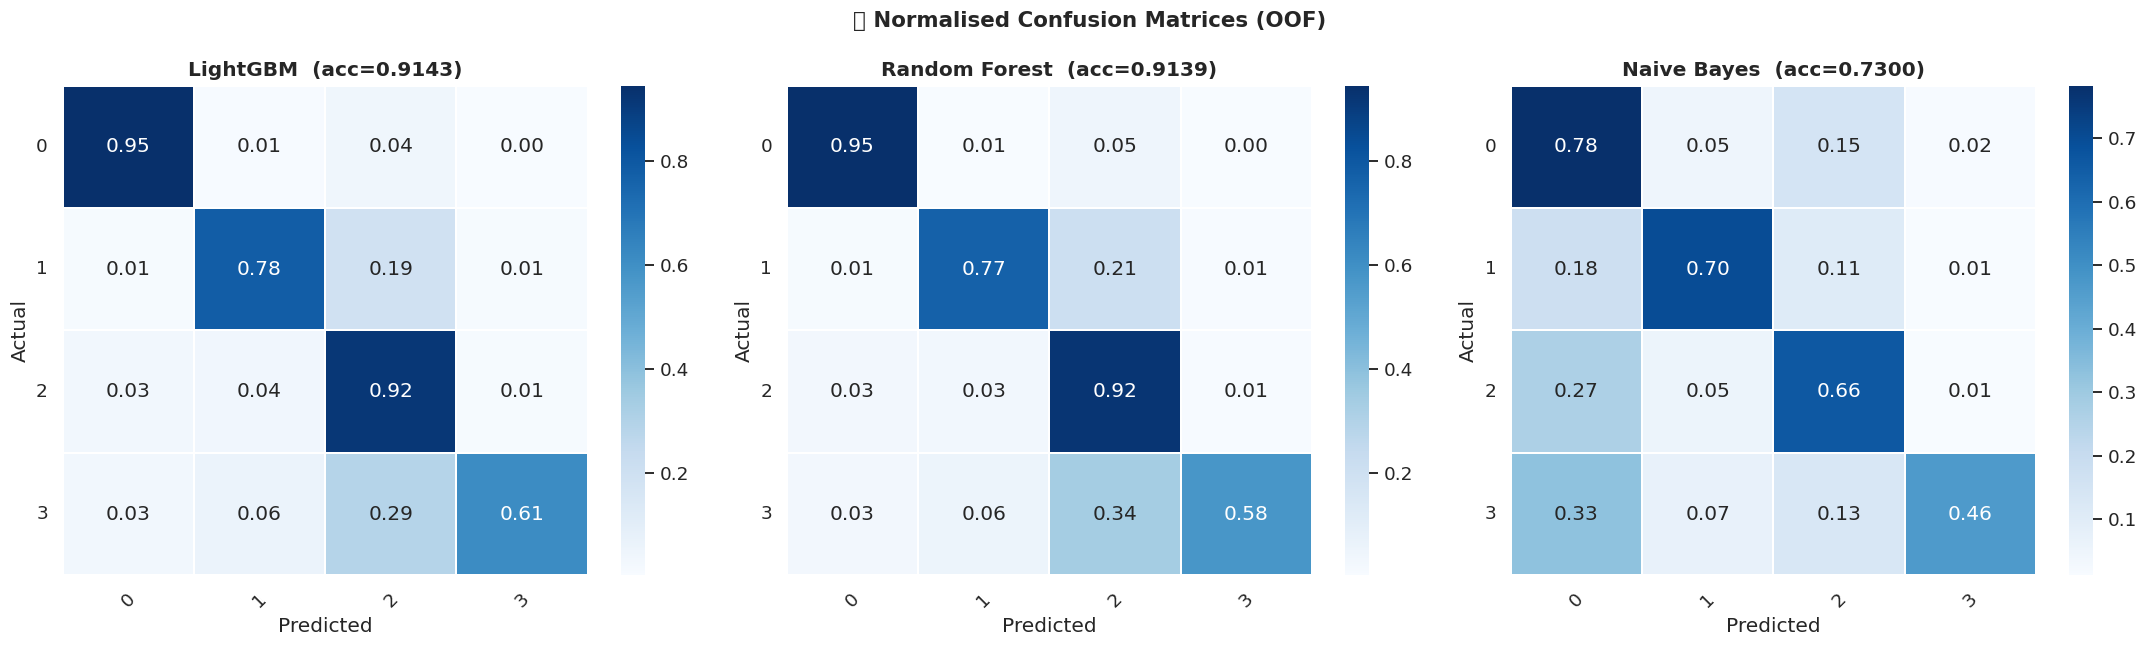

In [26]:
# ============================================================
# 📌 CELL 24: CONFUSION MATRICES  (OOF predictions)
# ============================================================
# Insight: The confusion matrix shows which categories are most
# commonly confused with each other — helpful for error analysis.

def plot_cm(oof_pred, y, title, ax):
    y_pred = np.argmax(oof_pred, axis=1)
    cm = confusion_matrix(y, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Blues', ax=ax,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.3
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_cm(lgb_oof, y, f'LightGBM  (acc={lgb_acc:.4f})',           axes[0])
plot_cm(rf_oof,  y, f'Random Forest  (acc={rf_acc:.4f})',        axes[1])
plot_cm(nb_oof,  y, f'Naive Bayes  (acc={nb_acc:.4f})',          axes[2])

plt.suptitle('🔍 Normalised Confusion Matrices (OOF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 📌 CELL 25: CLASSIFICATION REPORT — BEST MODEL
# ============================================================

best_acc  = max(lgb_acc, rf_acc, nb_acc)
best_name = ['LightGBM', 'Random Forest', f'Naive Bayes ({best_nb_name})'][
    np.argmax([lgb_acc, rf_acc, nb_acc])
]
best_oof  = [lgb_oof, rf_oof, nb_oof][np.argmax([lgb_acc, rf_acc, nb_acc])]

print(f'📌 Best model: {best_name}  (CV acc = {best_acc:.4f})')
print()
print(classification_report(
    y, np.argmax(best_oof, axis=1),
    target_names=[str(c) for c in le.classes_]
))

📌 Best model: LightGBM  (CV acc = 0.9143)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96    114173
           1       0.78      0.78      0.78     15918
           2       0.86      0.92      0.89     62440
           3       0.71      0.61      0.66      5469

    accuracy                           0.91    198000
   macro avg       0.83      0.81      0.82    198000
weighted avg       0.92      0.91      0.91    198000



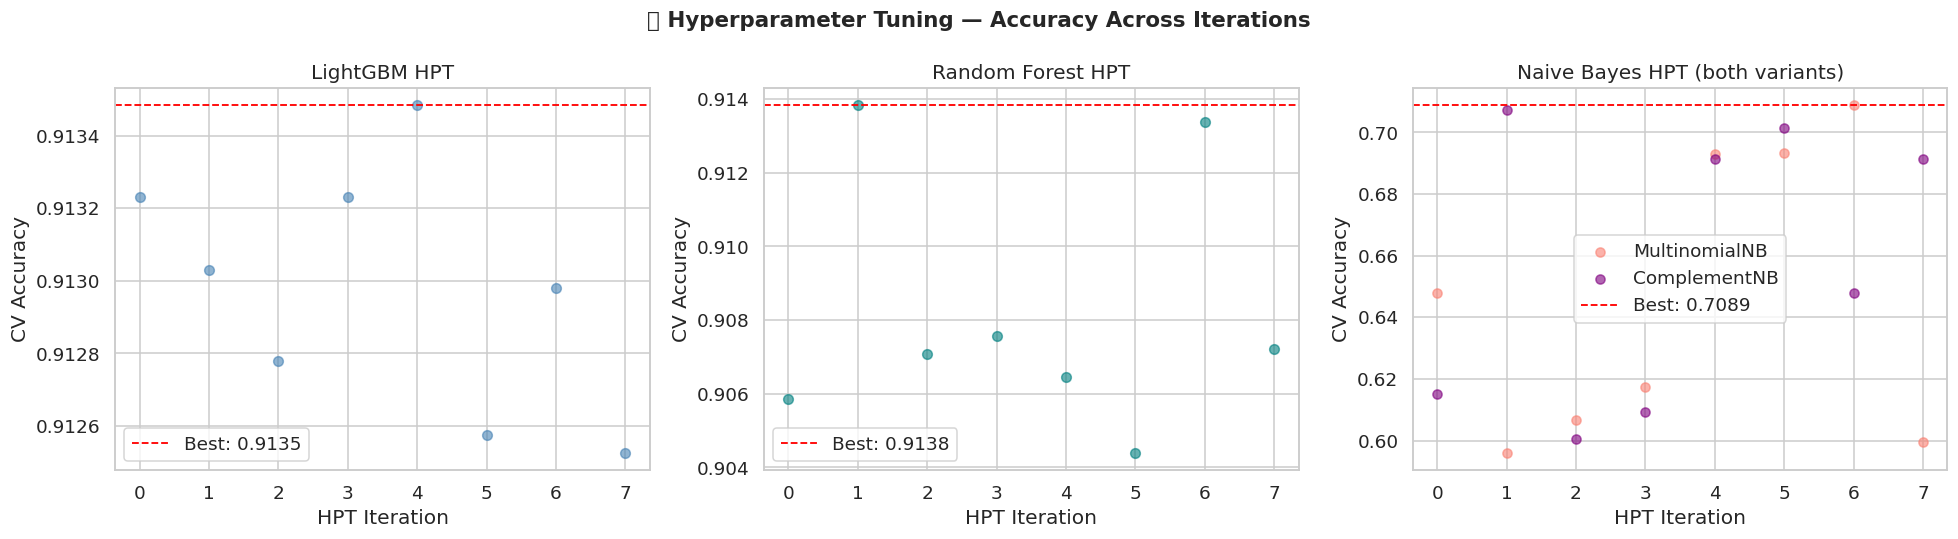

In [28]:
# ============================================================
# 📌 CELL 26: HPT RESULTS — SEARCH CURVE VISUALISATION
# ============================================================
# Show how accuracy varied across HPT iterations for each model.

def plot_hpt_curve(search_obj, title, ax, color):
    results  = pd.DataFrame(search_obj.cv_results_)
    scores   = results['mean_test_score'].values
    best_idx = np.argmax(scores)

    ax.scatter(range(len(scores)), scores, color=color, alpha=0.6, s=40)
    ax.axhline(scores[best_idx], color='red', linestyle='--', linewidth=1.2,
               label=f'Best: {scores[best_idx]:.4f}')
    ax.set_title(title)
    ax.set_xlabel('HPT Iteration')
    ax.set_ylabel('CV Accuracy')
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_hpt_curve(lgb_search, 'LightGBM HPT',      axes[0], 'steelblue')
plot_hpt_curve(rf_search,  'Random Forest HPT',  axes[1], 'teal')

# For NB: overlay both variant searches
mnb_scores = pd.DataFrame(mnb_search.cv_results_)['mean_test_score'].values
cnb_scores = pd.DataFrame(cnb_search.cv_results_)['mean_test_score'].values
axes[2].scatter(range(len(mnb_scores)), mnb_scores, color='salmon',  alpha=0.6, label='MultinomialNB')
axes[2].scatter(range(len(cnb_scores)), cnb_scores, color='purple',  alpha=0.6, label='ComplementNB')
axes[2].axhline(max(mnb_scores.max(), cnb_scores.max()), color='red',
                linestyle='--', linewidth=1.2,
                label=f'Best: {max(mnb_scores.max(), cnb_scores.max()):.4f}')
axes[2].set_title('Naive Bayes HPT (both variants)')
axes[2].set_xlabel('HPT Iteration')
axes[2].set_ylabel('CV Accuracy')
axes[2].legend()

plt.suptitle('📈 Hyperparameter Tuning — Accuracy Across Iterations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏁 Section 5 — Final Submission

In [29]:
# ============================================================
# 📌 CELL 27: FINAL SUBMISSION  (LightGBM as primary model)
# ============================================================
# Per the original notebook, LightGBM predictions are used for
# the final submission. The best_pred variable can be switched
# to rf_test or nb_test if those models score higher.

# --- Choose best predictions ---
best_pred_dict = {
    'LightGBM'     : lgb_test,
    'RandomForest' : rf_test,
    'NaiveBayes'   : nb_test,
}
best_model_name = max({'LightGBM': lgb_acc, 'RandomForest': rf_acc, 'NaiveBayes': nb_acc},
                      key=lambda k: {'LightGBM': lgb_acc, 'RandomForest': rf_acc, 'NaiveBayes': nb_acc}[k])

# 👉 Force LightGBM as primary (matching original notebook intent)
best_pred = lgb_test
print(f'📌 Submission uses: LightGBM  (CV acc = {lgb_acc:.4f})')
print(f'   (Auto-best would be: {best_model_name})')

# Decode predictions back to original label strings
sample['label'] = le.inverse_transform(np.argmax(best_pred, axis=1))

# Save submission
sample.to_csv('submission_final.csv', index=False)
print('\n✅ Submission saved → submission_final.csv')
sample.head(10)

📌 Submission uses: LightGBM  (CV acc = 0.9143)
   (Auto-best would be: LightGBM)

✅ Submission saved → submission_final.csv


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2


Label distribution comparison (train vs. submission):
       train_%  submission_%  abs_diff_%
label                                   
0        57.66         55.92        1.75
2        31.54         33.64        2.10
1         8.04          8.05        0.02
3         2.76          2.39        0.37


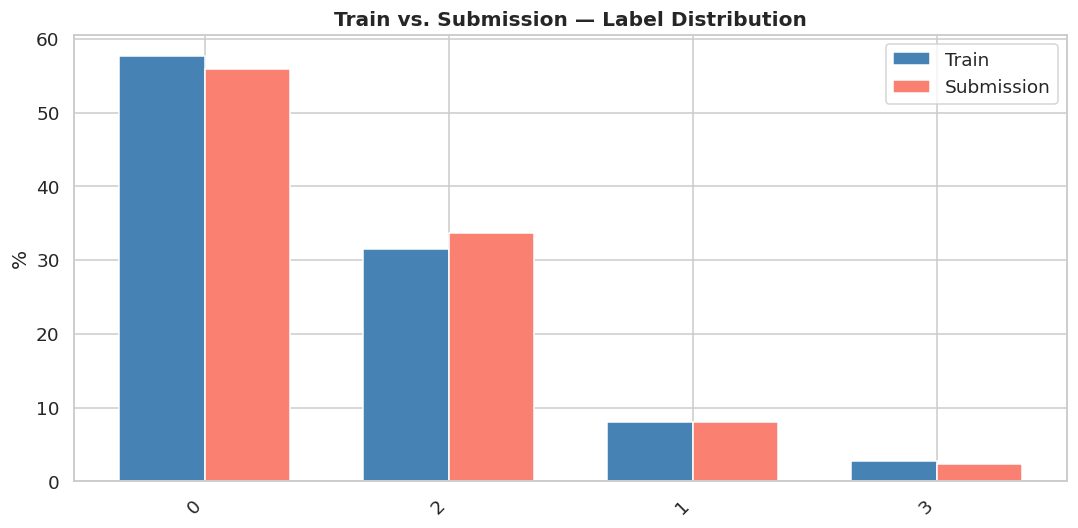

In [30]:
# ============================================================
# 📌 CELL 28: SUBMISSION LABEL DISTRIBUTION CHECK
# ============================================================
# Verify the predicted distribution broadly matches the training
# distribution — a big mismatch signals something is wrong.

train_dist = train['label'].value_counts(normalize=True).rename('train_%')
pred_dist  = sample['label'].value_counts(normalize=True).rename('submission_%')

dist_compare = pd.concat([train_dist, pred_dist], axis=1).fillna(0) * 100
dist_compare['abs_diff_%'] = (dist_compare['train_%'] - dist_compare['submission_%']).abs()

print('Label distribution comparison (train vs. submission):')
print(dist_compare.round(2).sort_values('train_%', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dist_compare))
w = 0.35
ax.bar(x - w/2, dist_compare['train_%'],      width=w, label='Train',      color='steelblue')
ax.bar(x + w/2, dist_compare['submission_%'], width=w, label='Submission', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(dist_compare.index, rotation=45, ha='right')
ax.set_ylabel('%')
ax.set_title('Train vs. Submission — Label Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()